# Panel Data Introduction

Panel data is the combination of cross-sectional and time series data. It follows ... 




To solve these issues, it is probably easiest to go through an example. So, let's look at a data set of co2 and carbon prices for $162$ countries over $29$ years since 1990.

In [80]:
%reset -f

In [81]:
from linearmodels.panel           import PooledOLS, RandomEffects, compare
from linearmodels                 import PanelOLS
from statsmodels.stats.diagnostic import het_white, het_breuschpagan
from statsmodels.stats.stattools  import durbin_watson
from scipy                        import stats

import numpy.linalg      as la
import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import statsmodels.api   as sm

In [82]:
data = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/regression_analysis/refs/heads/main/data/Co2.csv")

# transform them into index (categorical variables)

In [83]:
year = pd.Categorical(data.year)
iso_code  = pd.Categorical(data.iso_code)

# set panel id as "id" and "year" befpre checking the table

In [84]:
data = data.set_index(['iso_code', 'year'])

In [85]:
data['year'] = year
data['iso_code']  = iso_code

In [86]:
data['year'].dtypes

CategoricalDtype(categories=[1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
                  2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
                  2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018],
, ordered=False, categories_dtype=int64)

In [87]:
data['iso_code'].dtypes

CategoricalDtype(categories=['AFG', 'AGO', 'ALB', 'ARE', 'ARG', 'ARM', 'AUS', 'AUT',
                  'AZE', 'BDI',
                  ...
                  'UKR', 'URY', 'USA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZAF',
                  'ZMB', 'ZWE'],
, ordered=False, categories_dtype=str)

## create some helpful variables


In [88]:
data['gdp_per_cap'] = data['gdp'] / data['population']
data['ln_gdp_per_cap'] = np.log(data['gdp_per_cap'])
data['ln_co2_per_capita'] = np.log(data['co2_per_capita'])
data['ln_co2'] = np.log(data['co2'])
data['ln_Feed - in - Tariff'] = np.log(data['Feed - in - Tariff'] + 1)
data['CP'] = data['Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})']
data['ln_CP'] = np.log(data['CP']+1)
data['CP_DV'] = data['Carbon_price_DV']
data['ln_cumulative_co2'] = np.log(data['cumulative_co2'])

In [98]:
# create lists to call on each mod
y = "ln_co2_per_capita"
X = ['CP_DV', 
     "ln_gdp_per_cap",  
     'ln_Feed - in - Tariff', 
     'ln_CP']

In [99]:
data.columns

Index(['country', 'OECD', 'EU', 'co2', 'co2_growth_prct', 'co2_per_capita',
       'share_global_co2', 'cumulative_co2', 'share_global_cumulative_co2',
       'co2_per_gdp', 'population', 'gdp', 'Feed - in - Tariff',
       '% Share of Energy consumption from renewables', 'Carbon_price_DV',
       'Effective Carbon Price (Sum of {carbon price rate * proportion of countries CO2 covered})',
       'year', 'iso_code', 'gdp_per_cap', 'ln_gdp_per_cap',
       'ln_co2_per_capita', 'ln_co2', 'ln_Feed - in - Tariff', 'CP', 'ln_CP',
       'CP_DV', 'ln_cumulative_co2'],
      dtype='str')

# Pooled OLS




In [100]:
mod_ols = PooledOLS(data[y], sm.add_constant(data[X]))
pooled_res = mod_ols.fit(cov_type = 'clustered', cluster_entity = True)
print(pooled_res)    

                          PooledOLS Estimation Summary                          
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.8343
Estimator:                  PooledOLS   R-squared (Between):              0.8748
No. Observations:                4698   R-squared (Within):              -0.3094
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.8343
Time:                        18:22:46   Log-likelihood                   -4935.9
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      5906.1
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(4,4693)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             315.72
                            

# check homoskedasticity : residuals-Plot for growing variance Detection

* you can find that, as the predicted value increases, residual bandwidth changes
* hence, you need to use robust se

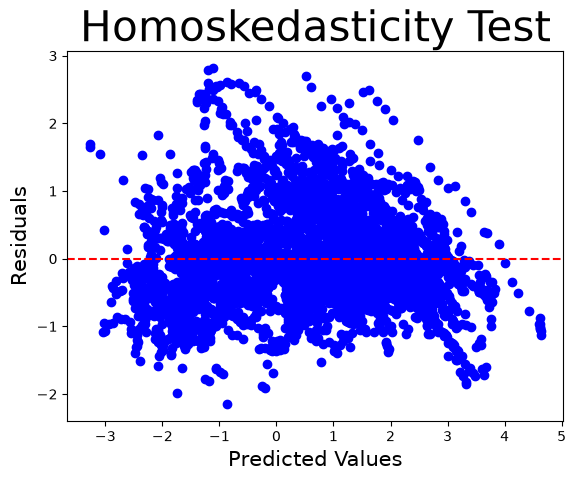

In [101]:
fittedvals_pooled_OLS = pooled_res.predict().fitted_values
residuals_pooled_OLS  = pooled_res.resids

fig, ax = plt.subplots()
ax.scatter(fittedvals_pooled_OLS, residuals_pooled_OLS, color = 'blue')
ax.axhline(0, color = 'r', ls = '--')
ax.set_xlabel('Predicted Values', fontsize = 15)
ax.set_ylabel('Residuals', fontsize = 15)
ax.set_title('Homoskedasticity Test', fontsize = 30)
plt.show()

## White-Test

In [102]:
pooled_OLS_dataset = pd.concat([data, residuals_pooled_OLS], axis=1)
white_test_results = het_white(pooled_OLS_dataset['residual'], sm.add_constant(data[X]))
labels = ['LM-Stat', 'LM p-val', 'F-Stat', 'F p-val'] 
print(dict(zip(labels, white_test_results)))

{'LM-Stat': np.float64(126.06604103601963), 'LM p-val': np.float64(3.793479947394618e-21), 'F-Stat': np.float64(10.76530937736882), 'F p-val': np.float64(1.89541147422357e-21)}


## Breusch-Pagan-Test

In [103]:
breusch_pagan_test_results = het_breuschpagan(pooled_OLS_dataset['residual'], sm.add_constant(data[X]))
print(dict(zip(labels, breusch_pagan_test_results)))

{'LM-Stat': np.float64(89.09397922000181), 'LM p-val': np.float64(2.050916149721582e-18), 'F-Stat': np.float64(22.679896411117674), 'F p-val': np.float64(1.4011506427710603e-18)}


## In simple terms, if p < 0.05, then heteroskedasticity is indicated. Both tests give very small p-values. Hence, we have heteroskedasticity

# now check autocorrelation
## Durbin-Watson-Test

In [104]:
durbin_watson_test_results = durbin_watson(pooled_OLS_dataset['residual']) 
print(durbin_watson_test_results)

0.13979711657695465


## The Durbin-Watson-Test will have one output between $0$ and $4$. The mean $(= 2)$ would indicate that there is no autocorrelation identified, $0$ to $2$ means positive autocorrelation (the nearer to zero the higher the correlation), and $2$ to $4$ means negative autocorrelation (the nearer to four the higher the correlation). In our example, the result is $0.5$, which clearly indicates strong positive autocorrelation.

# Random Effects




In [105]:

mod_re_rb = RandomEffects(data[y], sm.add_constant(data[X]))
re_res = mod_re_rb.fit(cov_type = 'clustered', cluster_entity = True)
print(re_res)

print(re_res.variance_decomposition)

                        RandomEffects Estimation Summary                        
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.3640
Estimator:              RandomEffects   R-squared (Between):              0.6051
No. Observations:                4698   R-squared (Within):               0.3169
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.5952
Time:                        18:22:48   Log-likelihood                   -588.14
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      671.35
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(4,4693)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             22.571
                            

# Fixed Effects



In [106]:

mod_fe = PanelOLS(data[y], sm.add_constant(data[X]), entity_effects = True, time_effects = True)
fe_res = mod_fe.fit(cov_type = 'clustered', cluster_entity = True)
print(fe_res)

                          PanelOLS Estimation Summary                           
Dep. Variable:      ln_co2_per_capita   R-squared:                        0.2417
Estimator:                   PanelOLS   R-squared (Between):              0.5944
No. Observations:                4698   R-squared (Within):               0.3184
Date:                Tue, Jun 23 2026   R-squared (Overall):              0.5849
Time:                        18:22:48   Log-likelihood                   -303.78
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      358.89
Entities:                         162   P-value                           0.0000
Avg Obs:                       29.000   Distribution:                  F(4,4504)
Min Obs:                       29.000                                           
Max Obs:                       29.000   F-statistic (robust):             19.380
                            

# Hausman Test




In [107]:
b = fe_res.params[1:6]
print(b)
B = re_res.params[1:6]
print(B)

CP_DV                   -0.146805
ln_gdp_per_cap           0.610321
ln_Feed - in - Tariff    0.054460
ln_CP                   -0.056025
Name: parameter, dtype: float64
CP_DV                   -0.173671
ln_gdp_per_cap           0.627838
ln_Feed - in - Tariff    0.021062
ln_CP                   -0.055573
Name: parameter, dtype: float64


In [108]:
v_b = fe_res.cov[1:6].drop(['const'], axis=1)
print(v_b)
v_B = re_res.cov[1:6].drop(['const'], axis=1)
print(v_B)

                          CP_DV  ln_gdp_per_cap  ln_Feed - in - Tariff  \
CP_DV                  0.003447        0.000130               0.000012   
ln_gdp_per_cap         0.000130        0.021527              -0.000756   
ln_Feed - in - Tariff  0.000012       -0.000756               0.001035   
ln_CP                 -0.000867       -0.000167               0.000085   

                          ln_CP  
CP_DV                 -0.000867  
ln_gdp_per_cap        -0.000167  
ln_Feed - in - Tariff  0.000085  
ln_CP                  0.000416  
                          CP_DV  ln_gdp_per_cap  ln_Feed - in - Tariff  \
CP_DV                  0.003491       -0.001765               0.000047   
ln_gdp_per_cap        -0.001765        0.006789              -0.001530   
ln_Feed - in - Tariff  0.000047       -0.001530               0.001341   
ln_CP                 -0.000882       -0.000312               0.000137   

                          ln_CP  
CP_DV                 -0.000882  
ln_gdp_per_cap      

In [109]:
b[np.abs(b) < 1e8].size

4

In [110]:
df = b[np.abs(b) < 1e8].size
chi2 = np.dot((b-B).T, la.inv(v_b - v_B).dot(b - B)) 
pval = stats.chi2.sf(chi2, df)


dict = {'chi-sq stat' : [chi2],
        'df' : [df],
        'p-value' : [pval]}
Hausman_df = pd.DataFrame(dict)

In [111]:
Hausman_df.round(3)

,chi-sq stat,df,p-value
0,11.156,4,0.025


# Compare the Final Results

Just as a nice example of how to create tables with our results, we can use the `compare` function from `linearmodels` to make a nice table as such:

In [112]:
print(compare({"FE": fe_res,
               "RE": re_res,
               "Pooled": pooled_res},
             precision =  "pvalues",
              stars = True))

                                      Model Comparison                                     
                                             FE                    RE                Pooled
-------------------------------------------------------------------------------------------
Dep. Variable                 ln_co2_per_capita     ln_co2_per_capita     ln_co2_per_capita
Estimator                              PanelOLS         RandomEffects             PooledOLS
No. Observations                           4698                  4698                  4698
Cov. Est.                             Clustered             Clustered             Clustered
R-squared                                0.2417                0.3640                0.8343
R-Squared (Within)                       0.3184                0.3169               -0.3094
R-Squared (Between)                      0.5944                0.6051                0.8748
R-Squared (Overall)                      0.5849                0.5952           

Overall, these results are relatively consistent with other (and more in depth) research on this topic: https://openresearch-repository.anu.edu.au/server/api/core/bitstreams/623b4b43-2b7e-4796-82b6-e601ab108361/content. 

More importantly for us, is that we can see how panel data estimators such as fixed or random effects can help ameliorate issues of enogeneity when randomisation might not be possible. They do not always results in a causal effect, but a generally more robust than cross-secitonal or pooled estimates. 

A great summary on the poisitves and benefits of fixed effects (fixed effects tend to be much more common in econometrics) is this paper by Matthias Collischon and Andreas Eberl: https://www.econstor.eu/bitstream/10419/288529/1/s11577-020-00699-8.pdf).